In [12]:
# Used to test the existing model with "common sense problems" 
import sys
import os

sys.path.append(os.path.abspath(".."))
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import chess

from tqdm import tqdm
from torch.utils.data import DataLoader

from model import NNUE

from dataset import extract_halfkp
from engine.eval import model_evaluate_board

import random
import matplotlib.pyplot as plt

In [2]:
def undo_tanh(score, clip=0.9999):
    """Invert the tanh normalization from transform_row: tanh(cp / 400) -> cp."""
    return np.arctanh(np.clip(score, -clip, clip)) * 400.0

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(device)

mps


In [5]:
model = NNUE().to(device)
checkpoint = torch.load("nnue_checkpoints/chess_model_large_final.pt", map_location=torch.device('cpu')) # cuda trained needs this key
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [8]:
# test 1, give three fen positions, see if engine can evaluate reasonably
# NOTE: eval is always from stm perspective.
def test1_common_sense(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    fen1 = "r1bqkb1r/pppp1ppp/2n2n2/4p1N1/2B1P3/8/PPPP1PPP/RNBQK2R b KQkq - 0 1" # normal opening position, (expected: small positive or near 0)
    print("fen1 (normal opening)      :", fmt(model_evaluate_board(model, chess.Board(fen1), device)))

    fen2 = "r1bNk2r/pppp2pp/2n4n/2b1p3/2B1P3/8/PPPP1PPP/RNBQK2R w KQkq - 0 1" # white has won a queen in the opening should be white winning (expected: high number)
    print("fen2 (white up queen)      :", fmt(model_evaluate_board(model, chess.Board(fen2), device)))

    fen3 = "rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq e3 0 1" # starting position white up a queen. should be white winning (expected: high number)
    print("fen3 (start + white queen) :", fmt(model_evaluate_board(model, chess.Board(fen3), device)))

    fen4 = "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 0 4" # mate in one for white and white to move (expected: high number)
    print("fen4 (mate in one)         :", fmt(model_evaluate_board(model, chess.Board(fen4), device)))

    fen5 = "r1bqkbn1/pppppppr/n6p/2QPP3/2P5/2N2NB1/PP2BPPP/3R1RK1 b q - 0 1" # (black tm) white is well developed but the queen is hanging (expected: medium high)
    print("fen5 (white Q hanging)     :", fmt(model_evaluate_board(model, chess.Board(fen5), device)))

#test1_common_sense(model, device)
test1_common_sense(model, device, True)

fen1 (normal opening)      : 128.4 cp
fen2 (white up queen)      : 419.2 cp
fen3 (start + white queen) : 419.2 cp
fen4 (mate in one)         : -69.8 cp
fen5 (white Q hanging)     : -409.6 cp


In [10]:
# test2: can the model value pieces; add a pawn, add a knight, add a bishop, add a rook, add a queen and should be < <= < <
def test_piece_values(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    base_fen = "rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1"

    # Add pieces one at a time for white
    pawn_board = chess.Board(base_fen)
    pawn_board.set_piece_at(chess.E4, chess.Piece(chess.PAWN, chess.WHITE))

    knight_board = chess.Board(base_fen)
    knight_board.set_piece_at(chess.E4, chess.Piece(chess.KNIGHT, chess.WHITE))

    bishop_board = chess.Board(base_fen)
    bishop_board.set_piece_at(chess.E4, chess.Piece(chess.BISHOP, chess.WHITE))

    rook_board = chess.Board(base_fen)
    rook_board.set_piece_at(chess.E4, chess.Piece(chess.ROOK, chess.WHITE))

    queen_board = chess.Board(base_fen)
    queen_board.set_piece_at(chess.E4, chess.Piece(chess.QUEEN, chess.WHITE))

    print("Pawn  :", fmt(model_evaluate_board(model, pawn_board, device)))
    print("Knight:", fmt(model_evaluate_board(model, knight_board, device)))
    print("Bishop:", fmt(model_evaluate_board(model, bishop_board, device)))
    print("Rook  :", fmt(model_evaluate_board(model, rook_board, device)))
    print("Queen :", fmt(model_evaluate_board(model, queen_board, device)))

test_piece_values(model, device, True)

Pawn  : 273.7 cp
Knight: 419.2 cp
Bishop: 419.2 cp
Rook  : 419.2 cp
Queen : 419.2 cp


In [11]:
# test3: sanity check if symmetry is correct
def test_color_symmetry(model, device, undo=False):
    def fmt(score):
        return f"{undo_tanh(score):.1f} cp" if undo else f"{score:.6f}"

    fen = "rnbqk3/ppNppp1p/1r3b1p/3P1N2/4PP2/P6P/2PQ2P1/1RB1KB1R b Kq - 0 1"
    
    board = chess.Board(fen)
    flipped = board.mirror()

    print(board, board.turn)
    print()
    print(flipped, flipped.turn)

    val1 = model_evaluate_board(model, board, device)
    val2 = model_evaluate_board(model, flipped, device)

    print("Original:", fmt(val1))
    print("Mirrored:", fmt(val2))

test_color_symmetry(model, device)

r n b q k . . .
p p N p p p . p
. r . . . b . p
. . . P . N . .
. . . . P P . .
P . . . . . . P
. . P Q . . P .
. R B . K B . R False

. r b . k b . r
. . p q . . p .
p . . . . . . p
. . . . p p . .
. . . p . n . .
. R . . . B . P
P P n P P P . P
R N B Q K . . . True
Original: -0.771452
Mirrored: -0.771452


Evaluating random positions: 100%|██████████| 500/500 [00:01<00:00, 299.56it/s]

n            : 492
mean         : 26.3515 centipawns
std          : 237.8018 centipawns
min          : -409.5613 centipawns
max          : 419.2023 centipawns
median       : 29.4491 centipawns
p25 / p75    : -145.2051 / 190.6910 centipawns
p5  / p95    : -409.5613 / 419.2023 centipawns


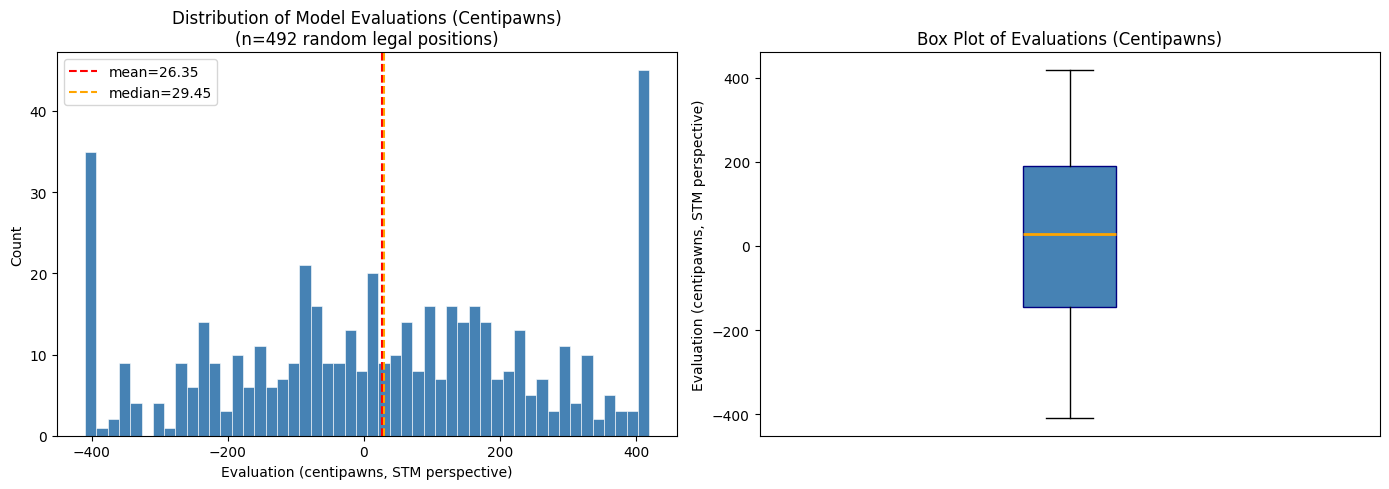

In [15]:
# test4: evaluate distribution of model scores on random legal positions
def generate_random_position(min_moves=10, max_moves=80):
    board = chess.Board()
    n_moves = random.randint(min_moves, max_moves)
    for _ in range(n_moves):
        if board.is_game_over():
            break
        move = random.choice(list(board.legal_moves))
        board.push(move)
    return board if not board.is_game_over() else None

def test4_random_eval_distribution(model, device, n_positions=500, seed=42, undo=False):
    random.seed(seed)
    scores = []

    for _ in tqdm(range(n_positions), desc="Evaluating random positions"):
        board = generate_random_position()
        if board is None:
            continue
        scores.append(model_evaluate_board(model, board, device))

    scores = np.array(scores)
    display = undo_tanh(scores) if undo else scores
    unit = "centipawns" if undo else "tanh score"

    # Stats
    print(f"n            : {len(display)}")
    print(f"mean         : {display.mean():.4f} {unit}")
    print(f"std          : {display.std():.4f} {unit}")
    print(f"min          : {display.min():.4f} {unit}")
    print(f"max          : {display.max():.4f} {unit}")
    print(f"median       : {np.median(display):.4f} {unit}")
    print(f"p25 / p75    : {np.percentile(display, 25):.4f} / {np.percentile(display, 75):.4f} {unit}")
    print(f"p5  / p95    : {np.percentile(display, 5):.4f} / {np.percentile(display, 95):.4f} {unit}")

    xlabel = f"Evaluation ({unit}, STM perspective)"
    title_unit = "Centipawns" if undo else "Tanh Score [-1, 1]"

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(display, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
    axes[0].axvline(display.mean(), color="red", linestyle="--", label=f"mean={display.mean():.2f}")
    axes[0].axvline(np.median(display), color="orange", linestyle="--", label=f"median={np.median(display):.2f}")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of Model Evaluations ({title_unit})\n(n={len(display)} random legal positions)")
    axes[0].legend()

    axes[1].boxplot(display, vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", color="navy"),
                    medianprops=dict(color="orange", linewidth=2))
    axes[1].set_ylabel(xlabel)
    axes[1].set_title(f"Box Plot of Evaluations ({title_unit})")
    axes[1].set_xticks([])

    plt.tight_layout()
    plt.show()

    return scores

scores = test4_random_eval_distribution(model, device, n_positions=500, undo=True)